# Employee Attrition Prediction — Exploratory Data Analysis

This notebook explores the IBM HR Analytics Employee Attrition dataset before data cleaning and model training.

## Objectives

- Inspect dataset shape, columns, and data types
- Check missing values and duplicate rows
- Analyze the target variable
- Explore numerical and categorical features
- Identify possible relationships with employee attrition
- Detect constant and identifier columns
- Save summary reports and figures

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Project Paths

The notebook expects the following project structure:

```text
employee-attrition-prediction/
├── data/
│   └── raw/
│       └── WA_Fn-UseC_-HR-Employee-Attrition.csv
├── notebooks/
│   └── 01_eda.ipynb
└── reports/
    └── figures/
```

In [ ]:
NOTEBOOK_DIR = Path.cwd()


PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "WA_Fn-UseC_-HR-Employee-Attrition.csv"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT.resolve())
print("Dataset path:", DATA_PATH.resolve())
print("Reports folder:", REPORTS_DIR.resolve())

Project root: C:\Users\Nasteho Abdi\employee-attrition-prediction
Dataset path: C:\Users\Nasteho Abdi\employee-attrition-prediction\data\raw\WA_Fn-UseC_-HR-Employee-Attrition.csv
Reports folder: C:\Users\Nasteho Abdi\employee-attrition-prediction\reports


In [3]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_PATH.resolve()}\n"
        "Place WA_Fn-UseC_-HR-Employee-Attrition.csv inside data/raw/."
    )

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully.
Rows: 1470
Columns: 35


## 2. Dataset Preview

In [4]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [5]:
df.sample(5, random_state=42)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1041,28,No,Travel_Rarely,866,Sales,5,3,Medical,1,1469,4,Male,84,3,2,Sales Executive,1,Single,8463,23490,0,Y,No,18,3,4,80,0,6,4,3,5,4,1,3
184,53,No,Travel_Rarely,1084,Research & Development,13,2,Medical,1,250,4,Female,57,4,2,Manufacturing Director,1,Divorced,4450,26250,1,Y,No,11,3,3,80,2,5,3,3,4,2,1,3
1222,24,Yes,Travel_Rarely,240,Human Resources,22,1,Human Resources,1,1714,4,Male,58,1,1,Human Resources,3,Married,1555,11585,1,Y,No,11,3,3,80,1,1,2,3,1,0,0,0
67,45,No,Travel_Rarely,1339,Research & Development,7,3,Life Sciences,1,86,2,Male,59,3,3,Research Scientist,1,Divorced,9724,18787,2,Y,No,17,3,3,80,1,25,2,3,1,0,0,0
220,36,No,Travel_Rarely,1396,Research & Development,5,2,Life Sciences,1,304,4,Male,62,3,2,Laboratory Technician,2,Single,5914,9945,8,Y,No,16,3,4,80,0,16,3,4,13,11,3,7


In [6]:
df.tail()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,3,Male,41,4,2,Laboratory Technician,4,Married,2571,12290,4,Y,No,17,3,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,4,Male,42,2,3,Healthcare Representative,1,Married,9991,21457,4,Y,No,15,3,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,2,Male,87,4,2,Manufacturing Director,2,Married,6142,5174,1,Y,Yes,20,4,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,4,Male,63,2,2,Sales Executive,2,Married,5390,13243,2,Y,No,14,3,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,2,Male,82,4,2,Laboratory Technician,3,Married,4404,10228,2,Y,No,12,3,1,80,0,6,3,4,4,3,1,2


## 3. Dataset Shape and Column Names

In [7]:
print(f"The dataset contains {df.shape[0]:,} employee records and {df.shape[1]} columns.")

The dataset contains 1,470 employee records and 35 columns.


In [8]:
for index, column in enumerate(df.columns, start=1):
    print(f"{index:02d}. {column}")

01. Age
02. Attrition
03. BusinessTravel
04. DailyRate
05. Department
06. DistanceFromHome
07. Education
08. EducationField
09. EmployeeCount
10. EmployeeNumber
11. EnvironmentSatisfaction
12. Gender
13. HourlyRate
14. JobInvolvement
15. JobLevel
16. JobRole
17. JobSatisfaction
18. MaritalStatus
19. MonthlyIncome
20. MonthlyRate
21. NumCompaniesWorked
22. Over18
23. OverTime
24. PercentSalaryHike
25. PerformanceRating
26. RelationshipSatisfaction
27. StandardHours
28. StockOptionLevel
29. TotalWorkingYears
30. TrainingTimesLastYear
31. WorkLifeBalance
32. YearsAtCompany
33. YearsInCurrentRole
34. YearsSinceLastPromotion
35. YearsWithCurrManager


## 4. Data Types and General Information

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [10]:
data_types_report = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Unique Values": [df[column].nunique(dropna=False) for column in df.columns]
})

data_types_report

,Column,Data Type,Unique Values
0,Age,int64,43
1,Attrition,str,2
2,BusinessTravel,str,3
3,DailyRate,int64,886
4,Department,str,3
5,DistanceFromHome,int64,29
6,Education,int64,5
7,EducationField,str,6
8,EmployeeCount,int64,1
9,EmployeeNumber,int64,1470


In [11]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"Numerical columns: {len(numerical_columns)}")
print(numerical_columns)

print(f"\nCategorical columns: {len(categorical_columns)}")
print(categorical_columns)

Numerical columns: 26
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical columns: 9
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


## 5. Missing Values

In [12]:
missing_report = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().mean() * 100).round(2)
}).sort_values("Missing Count", ascending=False)

print("Total missing values:", int(df.isnull().sum().sum()))
missing_report

Total missing values: 0


,Missing Count,Missing Percentage
Age,0,0.0
Attrition,0,0.0
BusinessTravel,0,0.0
DailyRate,0,0.0
Department,0,0.0
DistanceFromHome,0,0.0
Education,0,0.0
EducationField,0,0.0
EmployeeCount,0,0.0
EmployeeNumber,0,0.0


In [13]:
columns_with_missing_values = missing_report[
    missing_report["Missing Count"] > 0
]

if columns_with_missing_values.empty:
    print("No missing values were found.")
else:
    display(columns_with_missing_values)

No missing values were found.


## 6. Duplicate Rows

In [15]:
duplicate_count = int(df.duplicated().sum())
print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [16]:
if duplicate_count > 0:
    display(df[df.duplicated()].head())
else:
    print("No duplicate rows were found.")

No duplicate rows were found.


## 7. Descriptive Statistics

In [17]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [ ]:
df.describe(include=["object"]).T

## 8. Target Variable Analysis

In [18]:
TARGET_COLUMN = "Attrition"

if TARGET_COLUMN not in df.columns:
    raise ValueError(f"Target column '{TARGET_COLUMN}' was not found.")

print("Unique target values:", df[TARGET_COLUMN].unique())

Unique target values: <StringArray>
['Yes', 'No']
Length: 2, dtype: str


In [19]:
attrition_counts = df[TARGET_COLUMN].value_counts()
attrition_percentages = (
    df[TARGET_COLUMN]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

attrition_summary = pd.DataFrame({
    "Count": attrition_counts,
    "Percentage": attrition_percentages
})

attrition_summary

,Count,Percentage
Attrition,,
No,1233,83.88
Yes,237,16.12


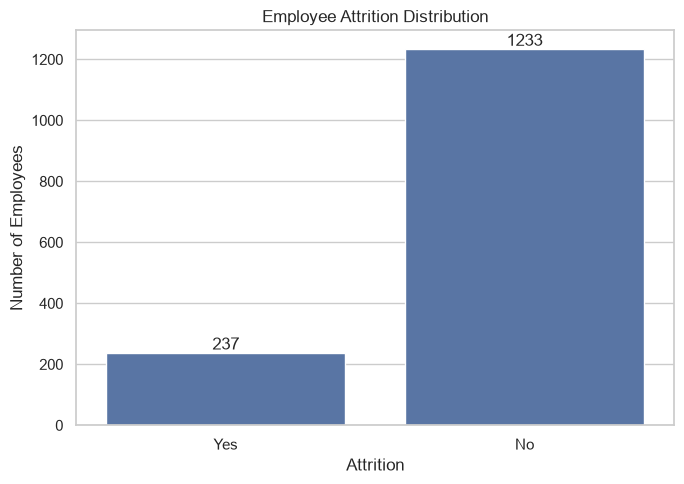

In [20]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x=TARGET_COLUMN)

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "attrition_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

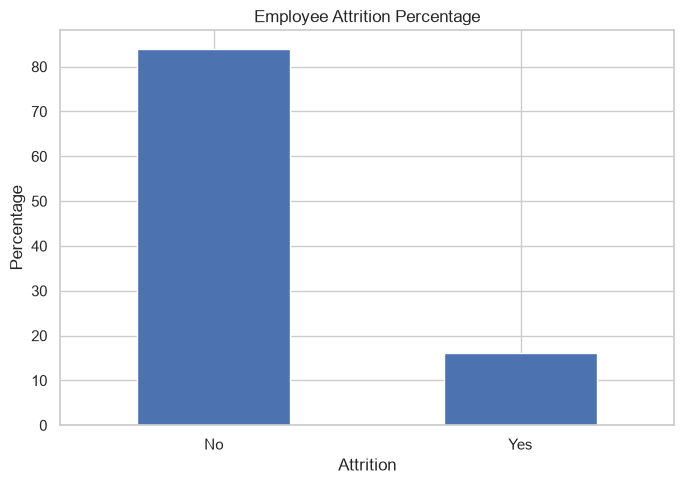

In [21]:
plt.figure(figsize=(7, 5))

attrition_percentages.plot(kind="bar")
plt.title("Employee Attrition Percentage")
plt.xlabel("Attrition")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "attrition_percentage.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Target Imbalance

The dataset is imbalanced because the number of employees who stayed is much larger than the number who left.

This means model evaluation should not depend on accuracy alone. Precision, recall, F1-score, confusion matrix, and ROC-AUC should also be considered.

## 9. Important Numerical Feature Distributions

In [22]:
important_numerical_features = [
    "Age",
    "MonthlyIncome",
    "DistanceFromHome",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "JobSatisfaction",
    "EnvironmentSatisfaction",
]

important_numerical_features = [
    column for column in important_numerical_features
    if column in df.columns
]

important_numerical_features

['Age',
 'MonthlyIncome',
 'DistanceFromHome',
 'TotalWorkingYears',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'JobSatisfaction',
 'EnvironmentSatisfaction']

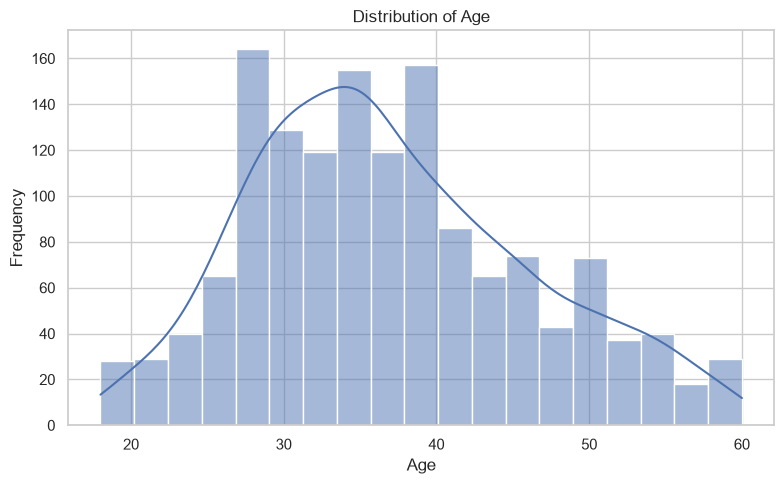

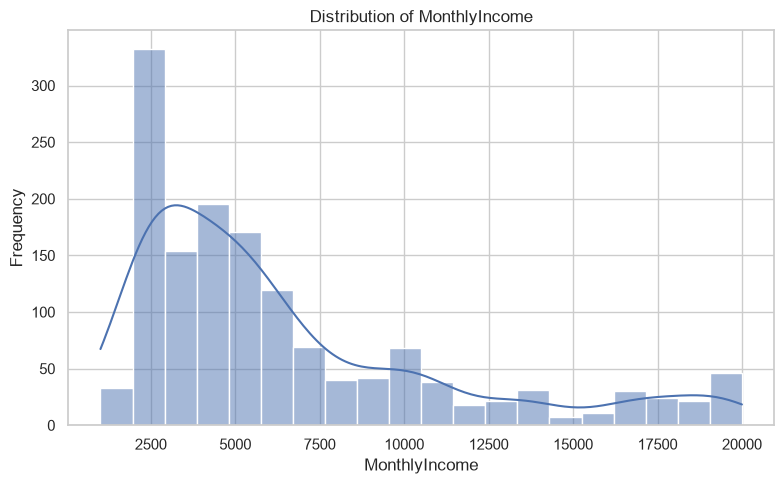

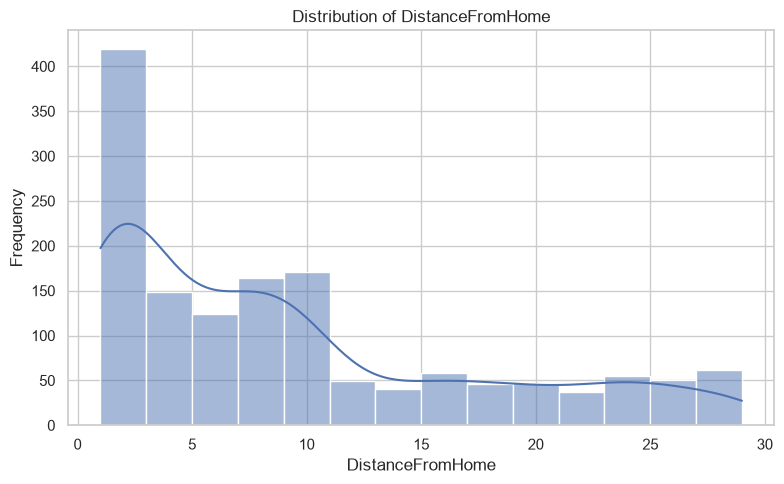

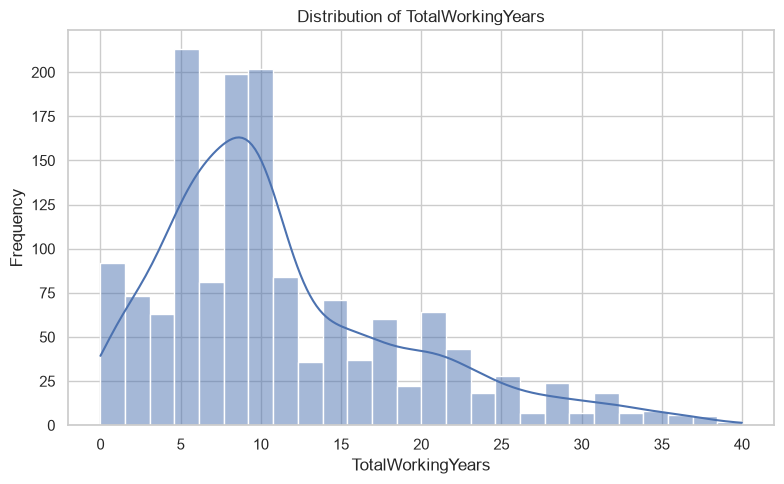

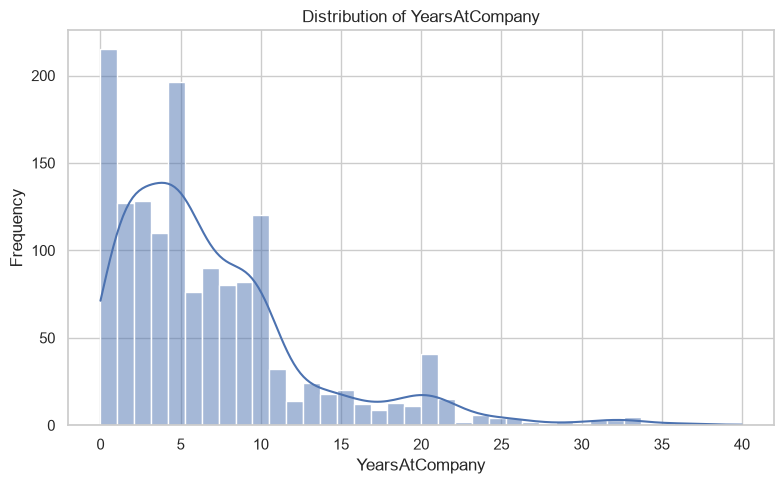

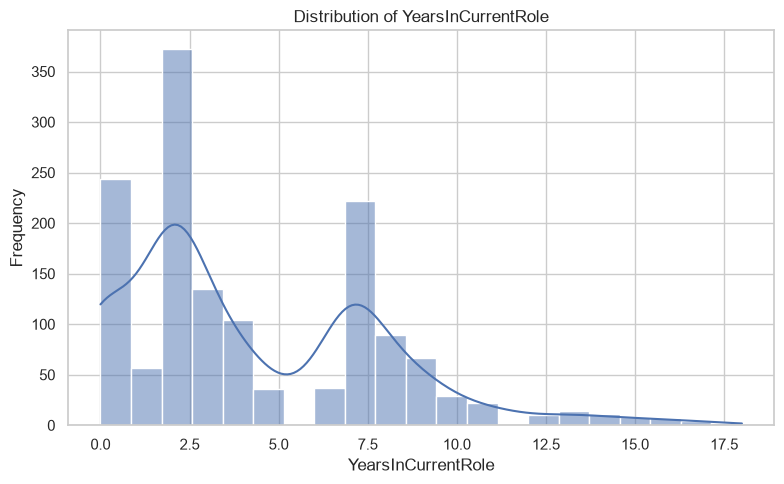

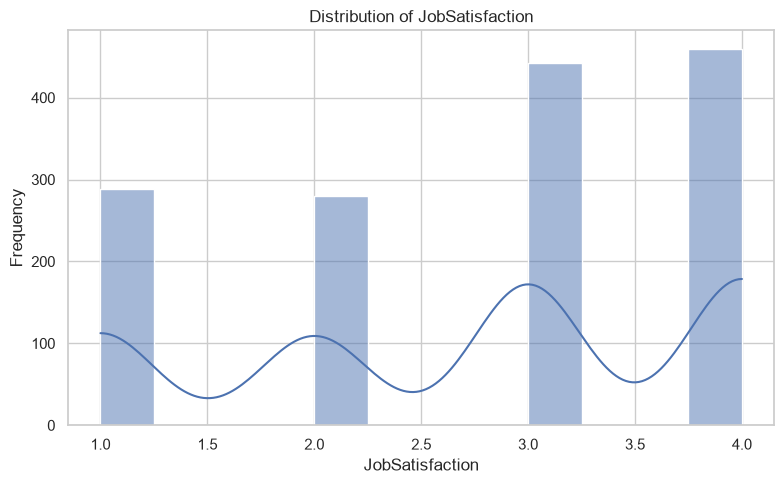

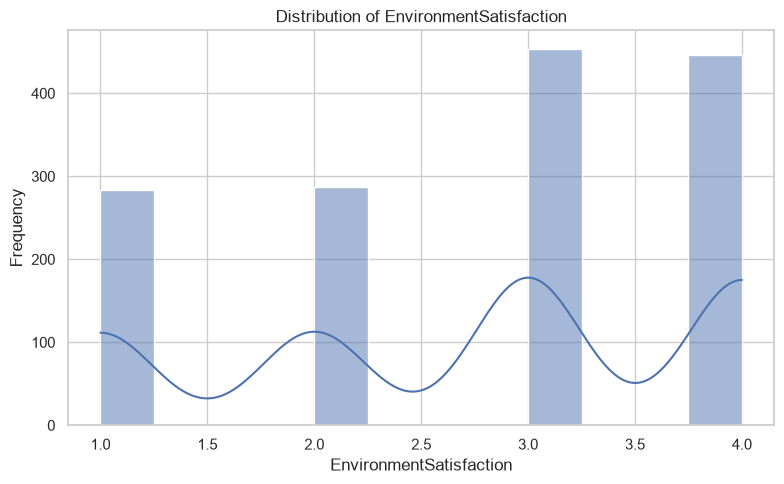

In [23]:
for column in important_numerical_features:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=column, kde=True)

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.tight_layout()

    filename = f"{column.lower()}_distribution.png"
    plt.savefig(
        FIGURES_DIR / filename,
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

## 10. Numerical Features Compared with Attrition

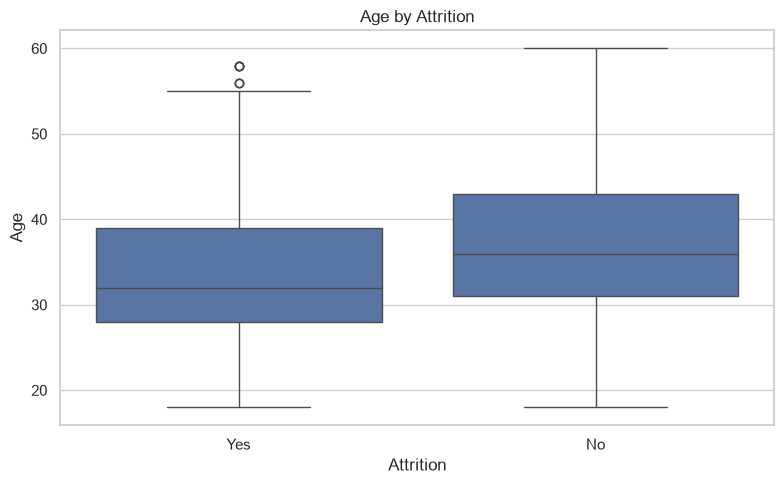

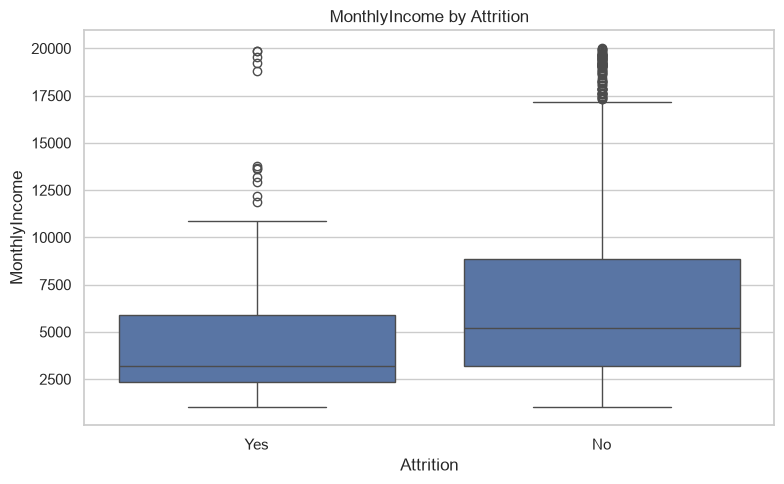

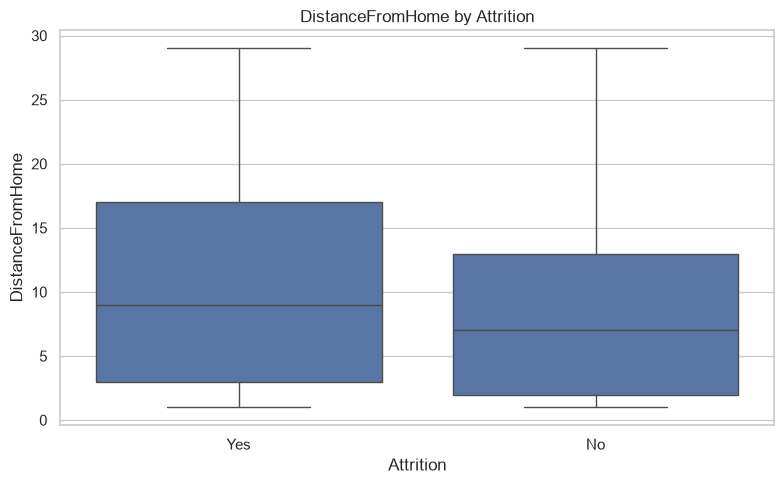

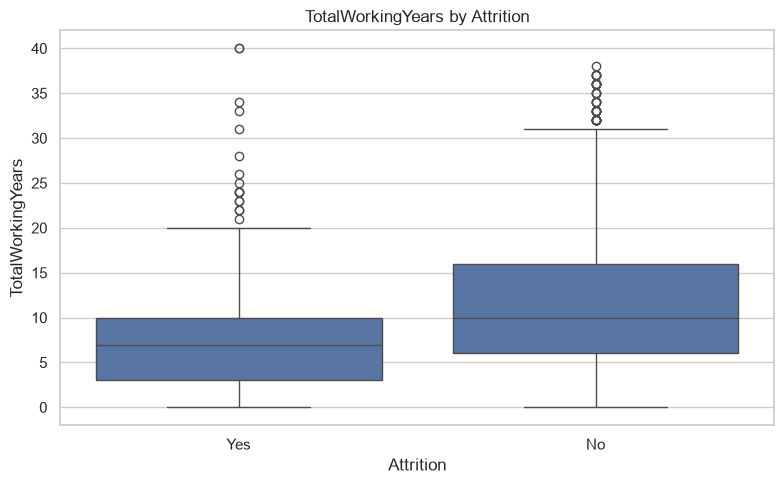

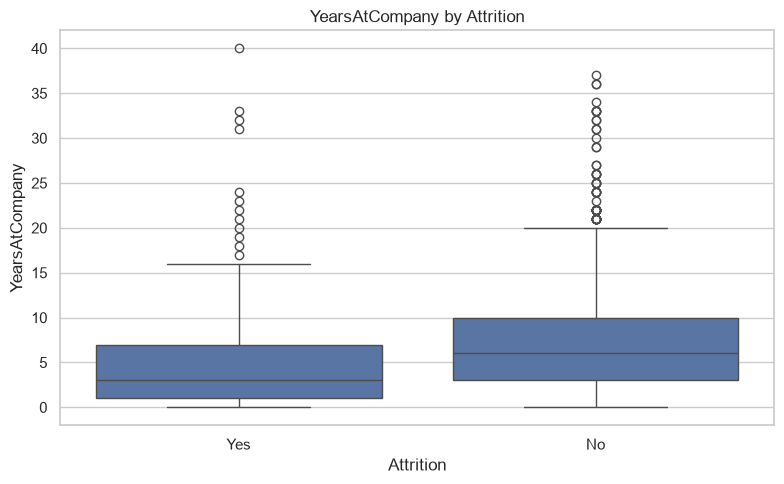

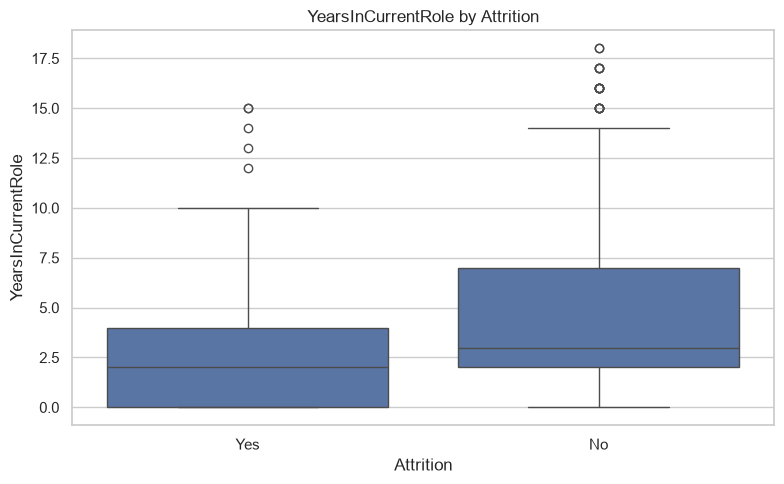

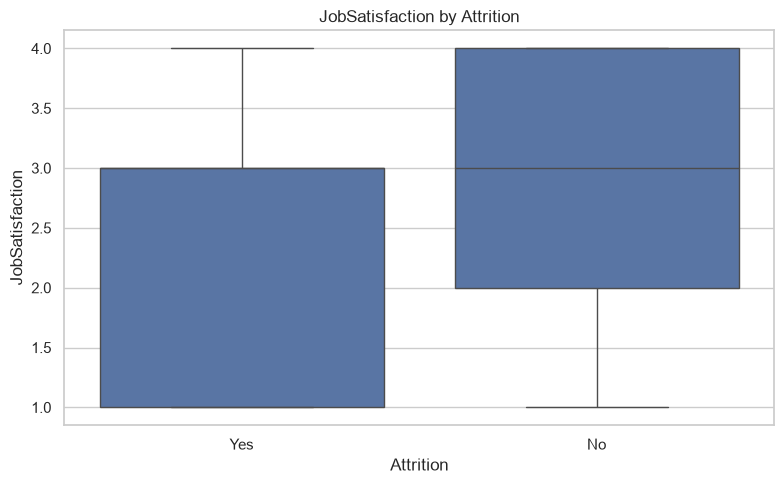

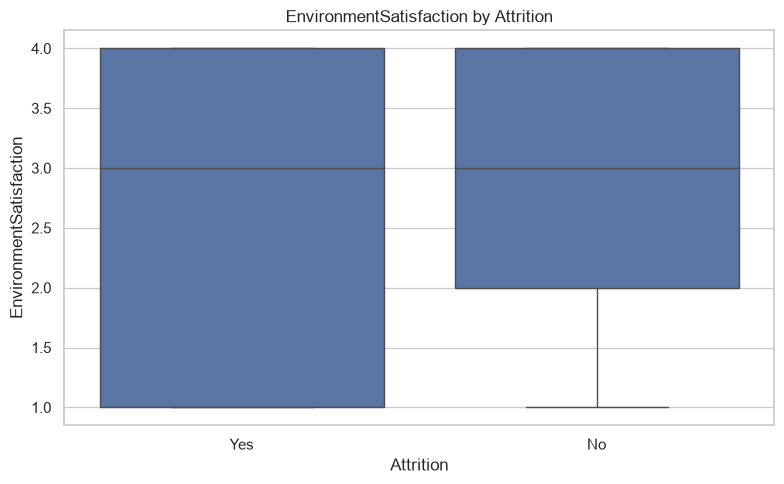

In [24]:
for column in important_numerical_features:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x=TARGET_COLUMN, y=column)

    plt.title(f"{column} by Attrition")
    plt.xlabel("Attrition")
    plt.ylabel(column)
    plt.tight_layout()

    filename = f"{column.lower()}_by_attrition.png"
    plt.savefig(
        FIGURES_DIR / filename,
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

In [25]:
numerical_attrition_comparison = (
    df.groupby(TARGET_COLUMN)[important_numerical_features]
    .mean()
    .round(2)
)

numerical_attrition_comparison

,Age,MonthlyIncome,DistanceFromHome,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,JobSatisfaction,EnvironmentSatisfaction
Attrition,,,,,,,,
No,37.56,6832.74,8.92,11.86,7.37,4.48,2.78,2.77
Yes,33.61,4787.09,10.63,8.24,5.13,2.90,2.47,2.46


## 11. Important Categorical Feature Distributions

In [26]:
important_categorical_features = [
    "BusinessTravel",
    "Department",
    "Gender",
    "JobRole",
    "MaritalStatus",
    "OverTime",
]

important_categorical_features = [
    column for column in important_categorical_features
    if column in df.columns
]

important_categorical_features

['BusinessTravel',
 'Department',
 'Gender',
 'JobRole',
 'MaritalStatus',
 'OverTime']

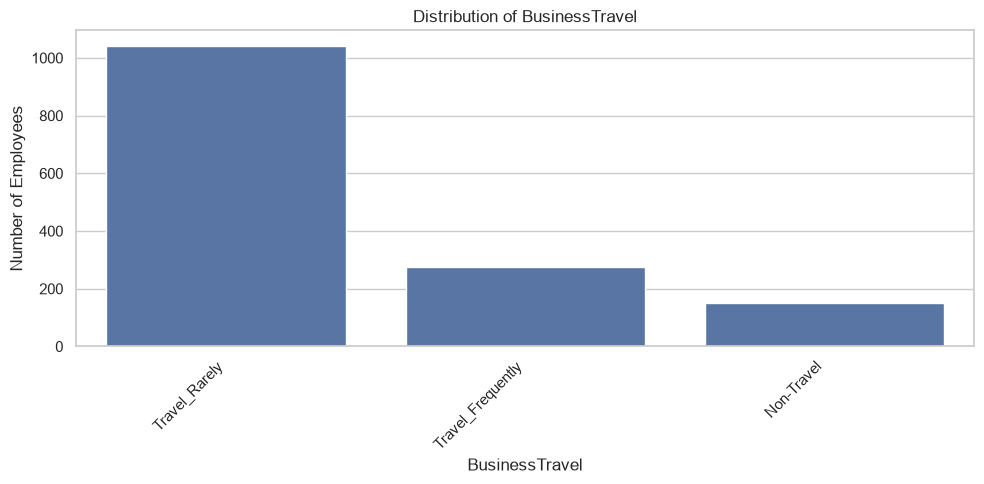

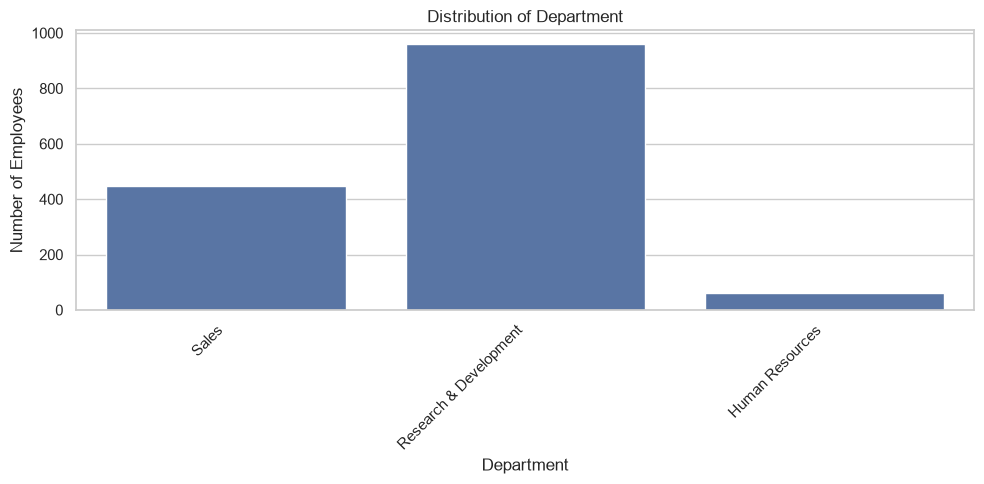

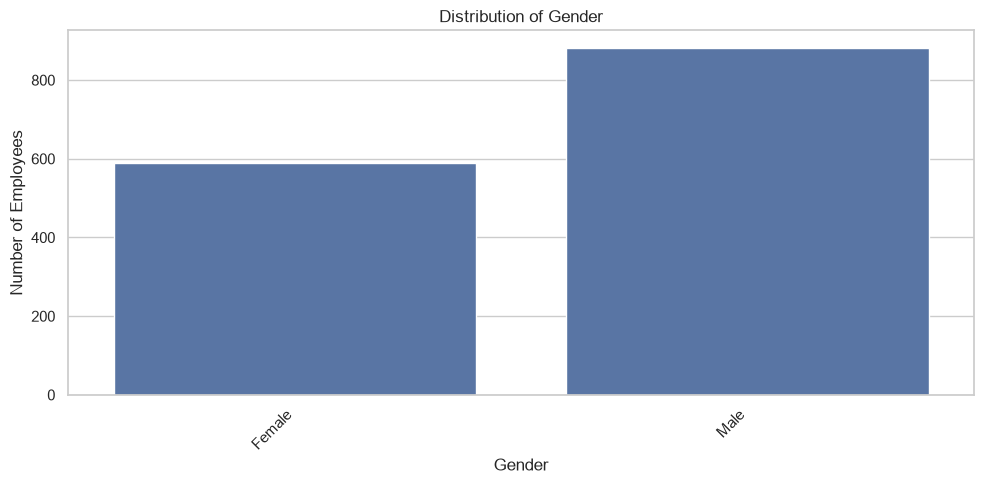

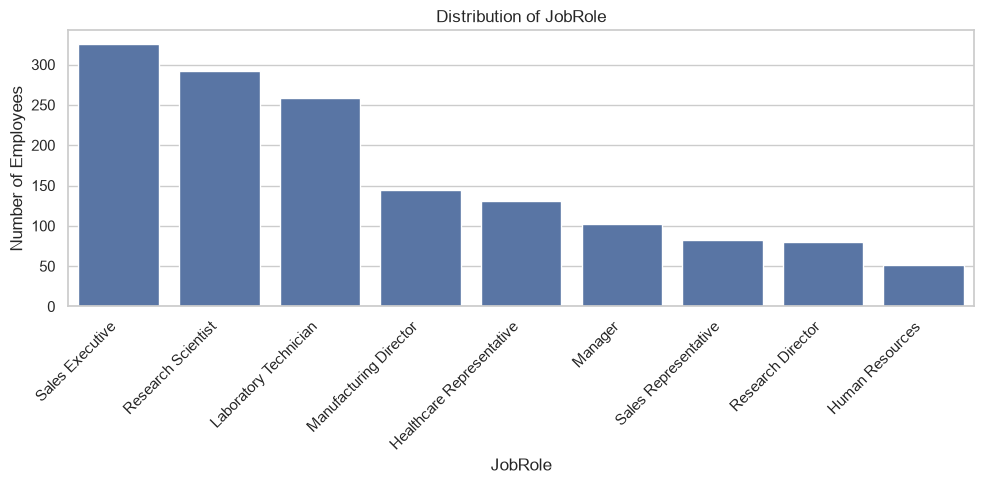

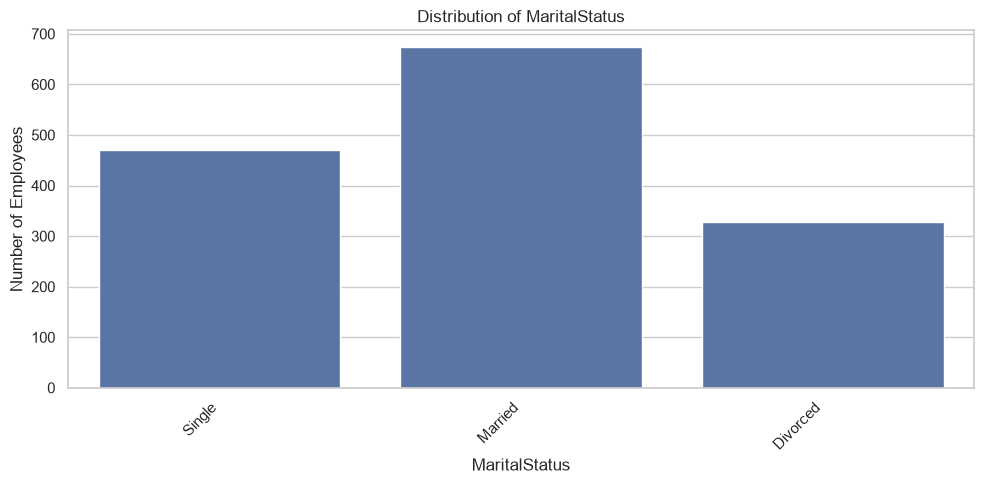

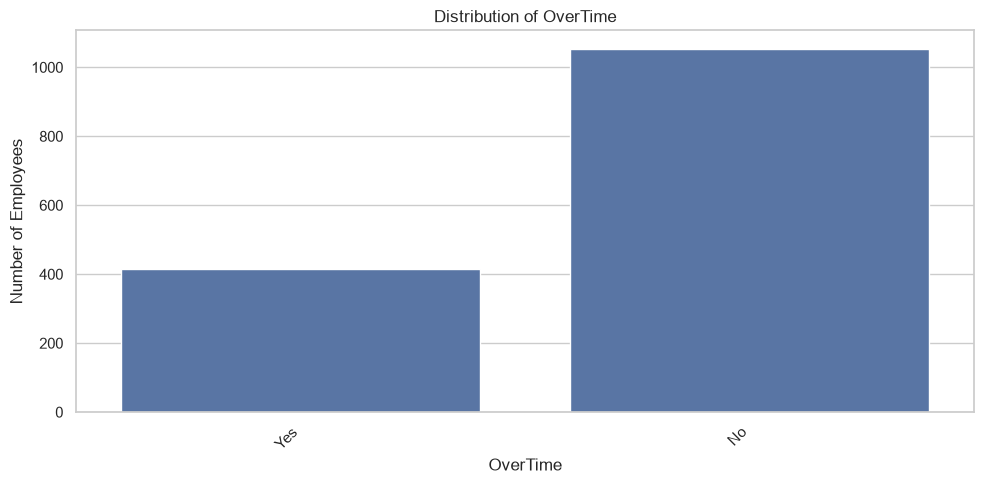

In [27]:
for column in important_categorical_features:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=column)

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Employees")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    filename = f"{column.lower()}_distribution.png"
    plt.savefig(
        FIGURES_DIR / filename,
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

## 12. Categorical Features Compared with Attrition

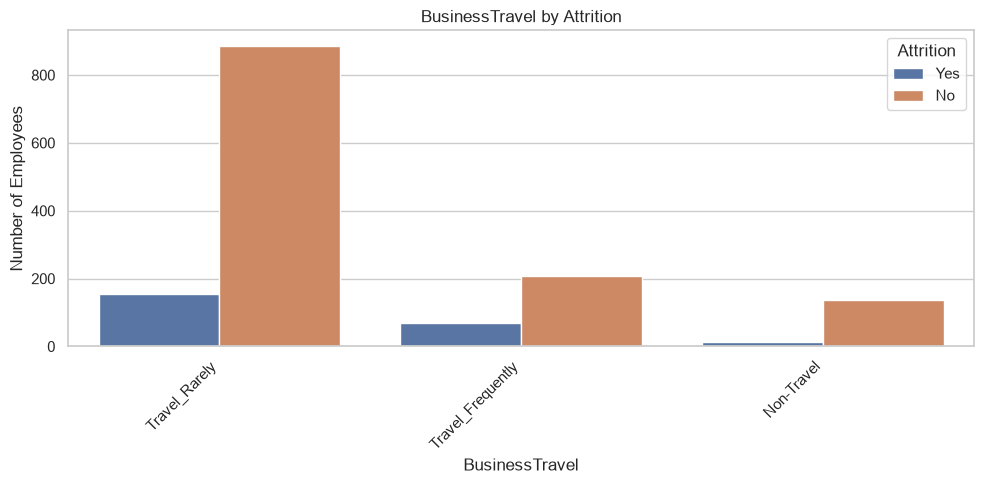

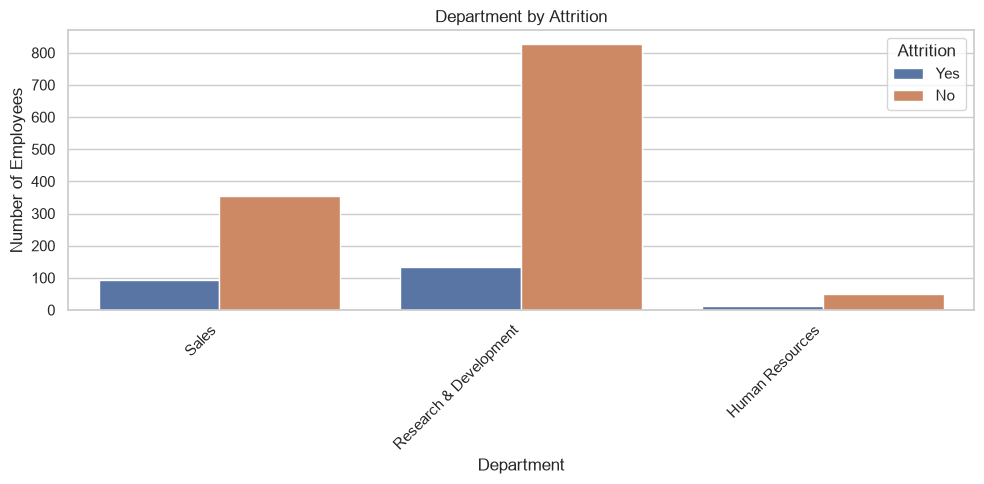

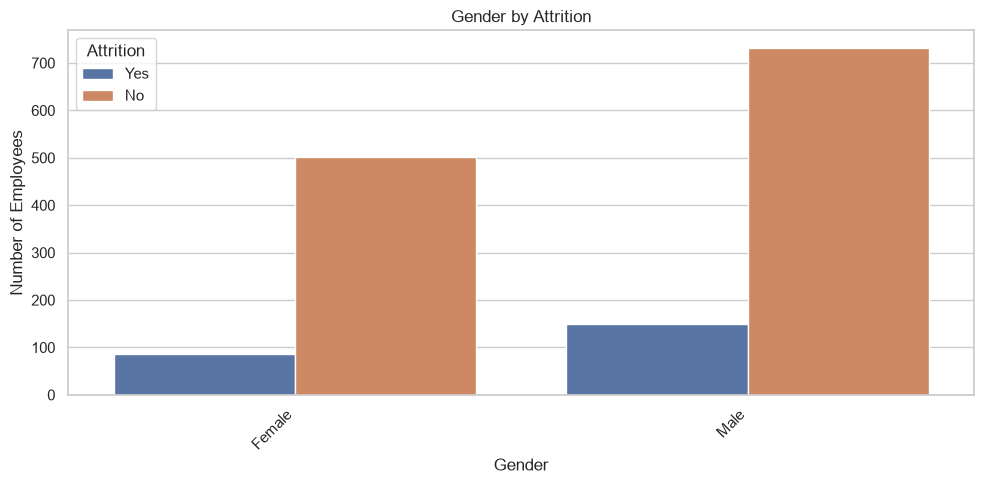

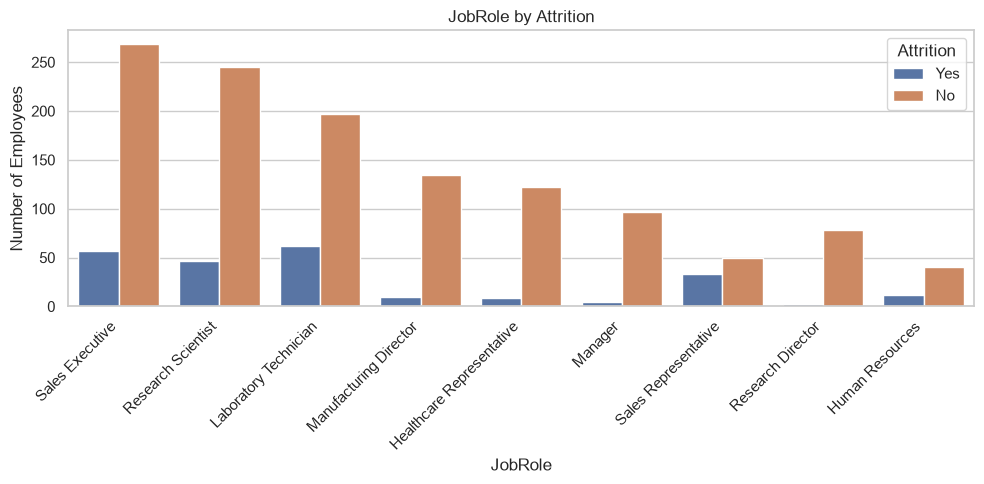

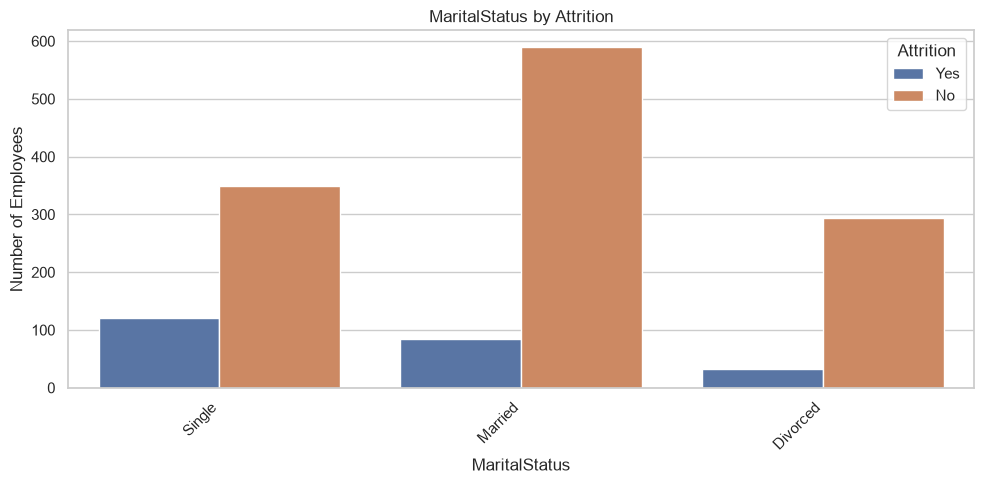

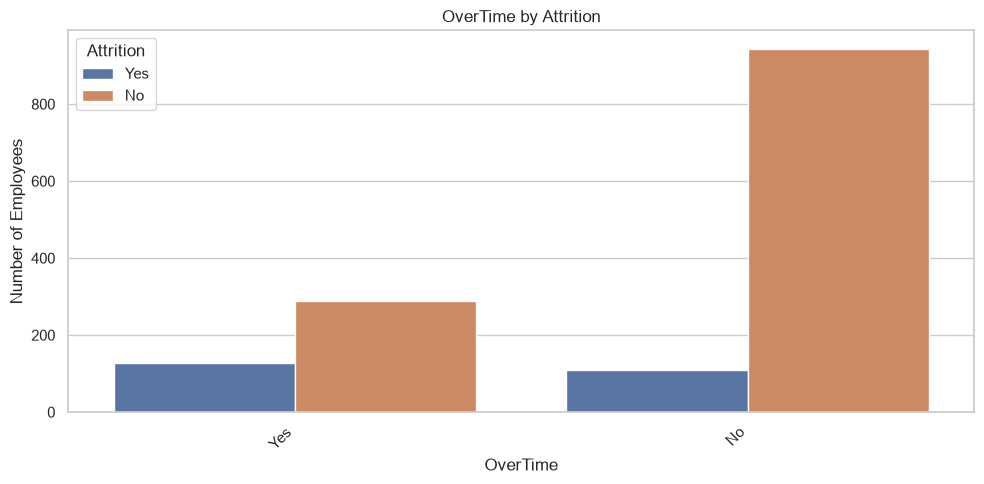

In [28]:
for column in important_categorical_features:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=column, hue=TARGET_COLUMN)

    plt.title(f"{column} by Attrition")
    plt.xlabel(column)
    plt.ylabel("Number of Employees")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    filename = f"{column.lower()}_by_attrition.png"
    plt.savefig(
        FIGURES_DIR / filename,
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

## 13. Attrition Rate by Category

Raw counts can be misleading when categories have different numbers of employees. Attrition rate shows the percentage of employees who left inside each category.

In [29]:
categorical_attrition_rates = {}

for column in important_categorical_features:
    rate = (
        df.groupby(column)[TARGET_COLUMN]
        .apply(lambda values: (values == "Yes").mean() * 100)
        .sort_values(ascending=False)
        .round(2)
    )

    categorical_attrition_rates[column] = rate

    print(f"\nAttrition rate by {column}:")
    display(rate.to_frame("Attrition Rate (%)"))


Attrition rate by BusinessTravel:


,Attrition Rate (%)
BusinessTravel,
Travel_Frequently,24.91
Travel_Rarely,14.96
Non-Travel,8.00



Attrition rate by Department:


,Attrition Rate (%)
Department,
Sales,20.63
Human Resources,19.05
Research & Development,13.84



Attrition rate by Gender:


...

,Attrition Rate (%)
JobRole,
Sales Representative,39.76
Laboratory Technician,23.94
Human Resources,23.08
Sales Executive,17.48
Research Scientist,16.10
Manufacturing Director,6.90
Healthcare Representative,6.87
Manager,4.90
Research Director,2.50



Attrition rate by MaritalStatus:


,Attrition Rate (%)
MaritalStatus,
Single,25.53
Married,12.48
Divorced,10.09



Attrition rate by OverTime:


,Attrition Rate (%)
OverTime,
Yes,30.53
No,10.44


## 14. Overtime Analysis

In [30]:
overtime_table = pd.crosstab(
    df["OverTime"],
    df[TARGET_COLUMN],
    margins=True
)

overtime_table

Attrition,No,Yes,All
OverTime,,,
No,944,110,1054
Yes,289,127,416
All,1233,237,1470


In [ ]:
overtime_percentage = pd.crosstab(
    df["OverTime"],
    df[TARGET_COLUMN],
    normalize="index"
).mul(100).round(2)

overtime_percentage

In [ ]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="OverTime", hue=TARGET_COLUMN)

plt.title("Attrition by Overtime Status")
plt.xlabel("Overtime")
plt.ylabel("Number of Employees")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "attrition_by_overtime.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 15. Job Role Analysis

In [31]:
job_role_attrition_rate = (
    df.groupby("JobRole")[TARGET_COLUMN]
    .apply(lambda values: (values == "Yes").mean() * 100)
    .sort_values(ascending=False)
    .round(2)
)

job_role_attrition_rate.to_frame("Attrition Rate (%)")

,Attrition Rate (%)
JobRole,
Sales Representative,39.76
Laboratory Technician,23.94
Human Resources,23.08
Sales Executive,17.48
Research Scientist,16.10
Manufacturing Director,6.90
Healthcare Representative,6.87
Manager,4.90
Research Director,2.50


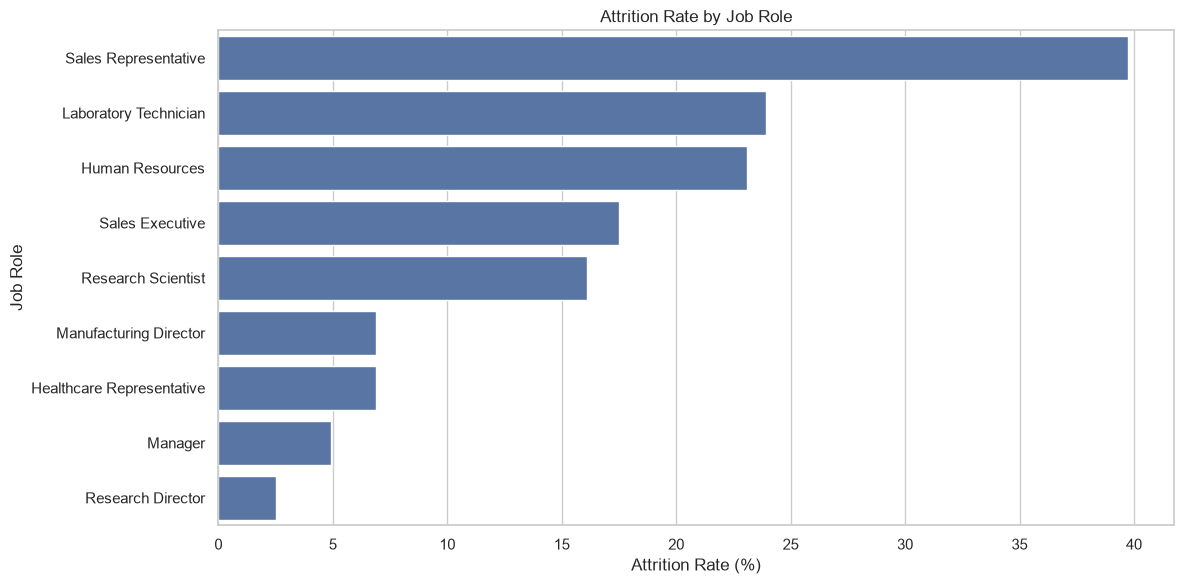

In [32]:
plt.figure(figsize=(12, 6))
sns.barplot(
    x=job_role_attrition_rate.values,
    y=job_role_attrition_rate.index
)

plt.title("Attrition Rate by Job Role")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Job Role")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "attrition_rate_by_job_role.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 16. Department Analysis

In [33]:
department_attrition_rate = (
    df.groupby("Department")[TARGET_COLUMN]
    .apply(lambda values: (values == "Yes").mean() * 100)
    .sort_values(ascending=False)
    .round(2)
)

department_attrition_rate.to_frame("Attrition Rate (%)")

,Attrition Rate (%)
Department,
Sales,20.63
Human Resources,19.05
Research & Development,13.84


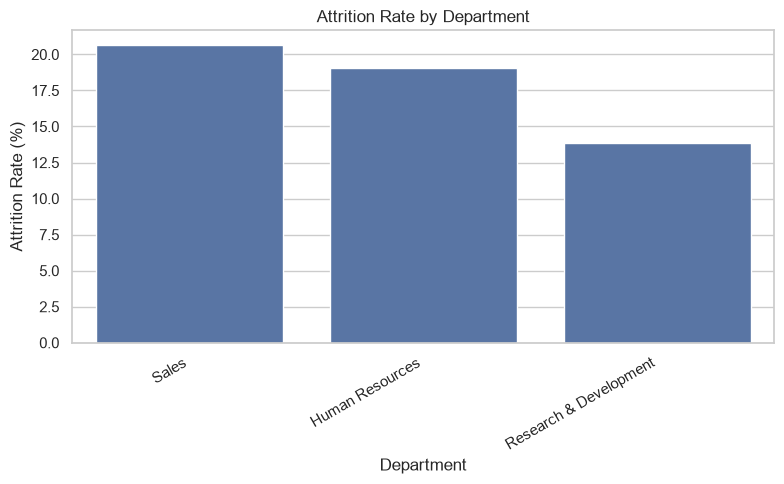

In [34]:
plt.figure(figsize=(8, 5))
sns.barplot(
    x=department_attrition_rate.index,
    y=department_attrition_rate.values
)

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "attrition_rate_by_department.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 17. Correlation Analysis

In [35]:
eda_df = df.copy()

eda_df["AttritionNumeric"] = eda_df[TARGET_COLUMN].map({
    "No": 0,
    "Yes": 1
})

correlation_columns = numerical_columns + ["AttritionNumeric"]
correlation_matrix = eda_df[correlation_columns].corr()

correlation_matrix

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,AttritionNumeric
Age,1.000000,0.010661,-0.001686,0.208034,NaN,-0.010145,0.010146,0.024287,0.029820,0.509604,-0.004892,0.497855,0.028051,0.299635,0.003634,0.001904,0.053535,NaN,0.037510,0.680381,-0.019621,-0.021490,0.311309,0.212901,0.216513,0.202089,-0.159205
DailyRate,0.010661,1.000000,-0.004985,-0.016806,NaN,-0.050990,0.018355,0.023381,0.046135,0.002966,0.030571,0.007707,-0.032182,0.038153,0.022704,0.000473,0.007846,NaN,0.042143,0.014515,0.002453,-0.037848,-0.034055,0.009932,-0.033229,-0.026363,-0.056652
DistanceFromHome,-0.001686,-0.004985,1.000000,0.021042,NaN,0.032916,-0.016075,0.031131,0.008783,0.005303,-0.003669,-0.017014,0.027473,-0.029251,0.040235,0.027110,0.006557,NaN,0.044872,0.004628,-0.036942,-0.026556,0.009508,0.018845,0.010029,0.014406,0.077924
Education,0.208034,-0.016806,0.021042,1.000000,NaN,0.042070,-0.027128,0.016775,0.042438,0.101589,-0.011296,0.094961,-0.026084,0.126317,-0.011111,-0.024539,-0.009118,NaN,0.018422,0.148280,-0.025100,0.009819,0.069114,0.060236,0.054254,0.069065,-0.031373
EmployeeCount,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeNumber,-0.010145,-0.050990,0.032916,0.042070,NaN,1.000000,0.017621,0.035179,-0.006888,-0.018519,-0.046247,-0.014829,0.012648,-0.001251,-0.012944,-0.020359,-0.069861,NaN,0.062227,-0.014365,0.023603,0.010309,-0.011240,-0.008416,-0.009019,-0.009197,-0.010577
EnvironmentSatisfaction,0.010146,0.018355,-0.016075,-0.027128,NaN,0.017621,1.000000,-0.049857,-0.008278,0.001212,-0.006784,-0.006259,0.037600,0.012594,-0.031701,-0.029548,0.007665,NaN,0.003432,-0.002693,-0.019359,0.027627,0.001458,0.018007,0.016194,-0.004999,-0.103369
HourlyRate,0.024287,0.023381,0.031131,0.016775,NaN,0.035179,-0.049857,1.000000,0.042861,-0.027853,-0.071335,-0.015794,-0.015297,0.022157,-0.009062,-0.002172,0.001330,NaN,0.050263,-0.002334,-0.008548,-0.004607,-0.019582,-0.024106,-0.026716,-0.020123,-0.006846
JobInvolvement,0.029820,0.046135,0.008783,0.042438,NaN,-0.006888,-0.008278,0.042861,1.000000,-0.012630,-0.021476,-0.015271,-0.016322,0.015012,-0.017205,-0.029071,0.034297,NaN,0.021523,-0.005533,-0.015338,-0.014617,-0.021355,0.008717,-0.024184,0.025976,-0.130016
JobLevel,0.509604,0.002966,0.005303,0.101589,NaN,-0.018519,0.001212,-0.027853,-0.012630,1.000000,-0.001944,0.950300,0.039563,0.142501,-0.034730,-0.021222,0.021642,NaN,0.013984,0.782208,-0.018191,0.037818,0.534739,0.389447,0.353885,0.375281,-0.169105


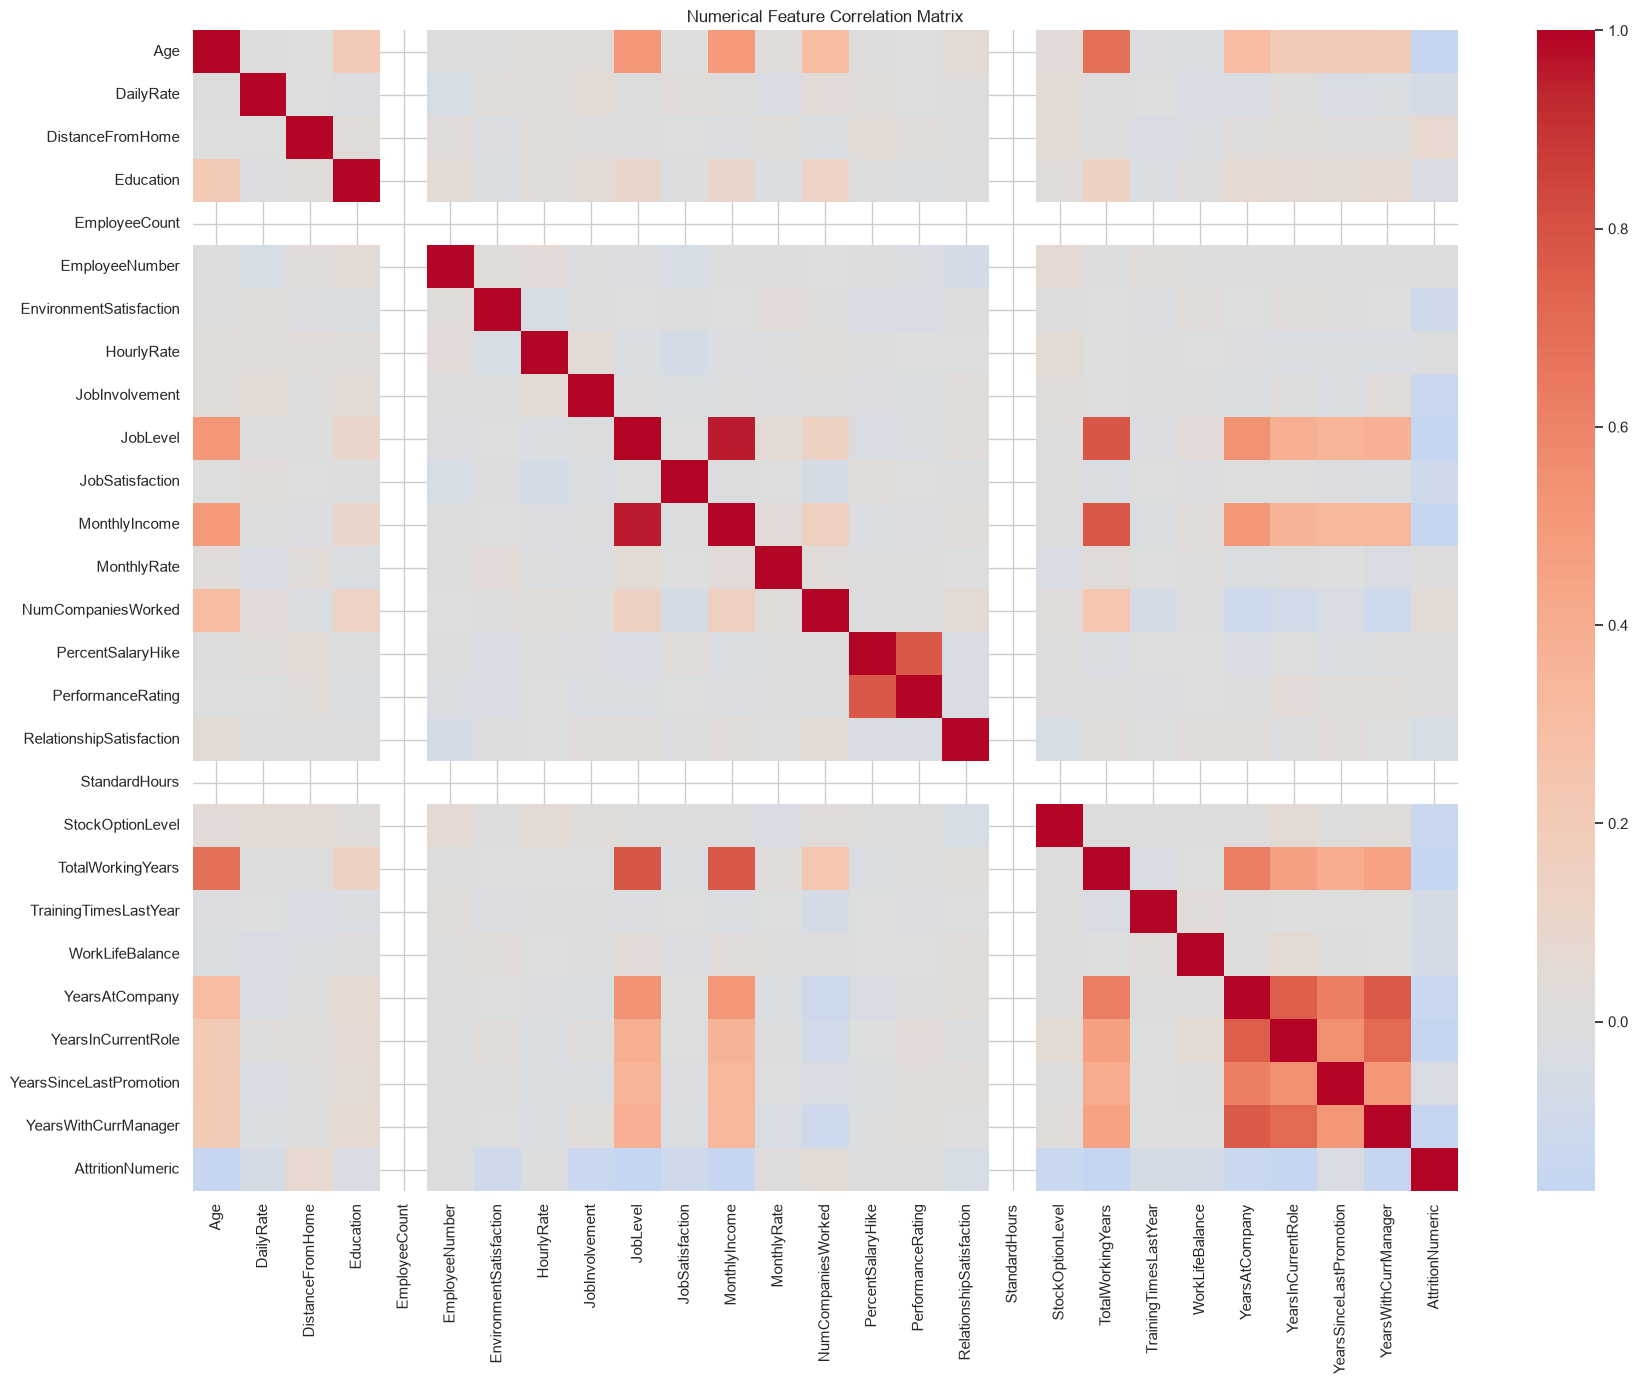

In [36]:
plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Numerical Feature Correlation Matrix")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [37]:
attrition_correlations = (
    correlation_matrix["AttritionNumeric"]
    .drop("AttritionNumeric")
    .sort_values(ascending=False)
)

attrition_correlations.to_frame("Correlation with Attrition")

,Correlation with Attrition
DistanceFromHome,0.077924
NumCompaniesWorked,0.043494
MonthlyRate,0.015170
PerformanceRating,0.002889
HourlyRate,-0.006846
EmployeeNumber,-0.010577
PercentSalaryHike,-0.013478
Education,-0.031373
YearsSinceLastPromotion,-0.033019
RelationshipSatisfaction,-0.045872


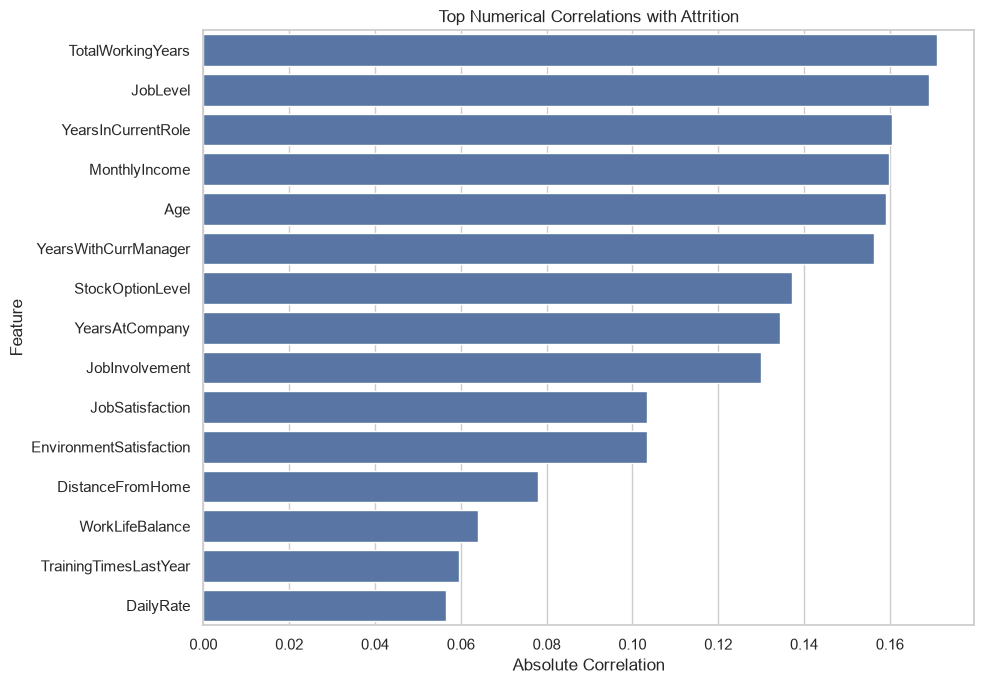

In [38]:
absolute_attrition_correlations = (
    attrition_correlations
    .abs()
    .sort_values(ascending=False)
)

top_correlations = absolute_attrition_correlations.head(15)

plt.figure(figsize=(10, 7))
sns.barplot(
    x=top_correlations.values,
    y=top_correlations.index
)

plt.title("Top Numerical Correlations with Attrition")
plt.xlabel("Absolute Correlation")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "top_attrition_correlations.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 18. Unique Values and Constant Columns

In [39]:
unique_values_report = pd.DataFrame({
    "Column": df.columns,
    "Unique Values": [
        df[column].nunique(dropna=False)
        for column in df.columns
    ]
}).sort_values("Unique Values")

unique_values_report

,Column,Unique Values
8,EmployeeCount,1
21,Over18,1
26,StandardHours,1
1,Attrition,2
22,OverTime,2
24,PerformanceRating,2
11,Gender,2
2,BusinessTravel,3
4,Department,3
17,MaritalStatus,3


In [40]:
constant_columns = [
    column
    for column in df.columns
    if df[column].nunique(dropna=False) == 1
]

print("Constant columns:", constant_columns)

Constant columns: ['EmployeeCount', 'Over18', 'StandardHours']


Constant columns contain the same value for every employee and do not provide useful predictive information. These columns should be removed during data cleaning.

## 19. Identifier Columns

In [41]:
possible_identifier_columns = []

for column in df.columns:
    if df[column].nunique(dropna=False) == len(df):
        possible_identifier_columns.append(column)

print("Possible identifier columns:", possible_identifier_columns)

Possible identifier columns: ['EmployeeNumber']


In [42]:
if "EmployeeNumber" in df.columns:
    print("Rows:", len(df))
    print("Unique EmployeeNumber values:", df["EmployeeNumber"].nunique())

Rows: 1470
Unique EmployeeNumber values: 1470


`EmployeeNumber` identifies individual employees. It should not be treated as a predictive feature because its value has no meaningful relationship with employee behavior.

## 20. Save EDA Reports

In [43]:
eda_summary = {
    "rows": int(df.shape[0]),
    "columns": int(df.shape[1]),
    "numerical_columns": len(numerical_columns),
    "categorical_columns": len(categorical_columns),
    "missing_values": int(df.isnull().sum().sum()),
    "duplicate_rows": int(df.duplicated().sum()),
    "attrition_yes_count": int((df[TARGET_COLUMN] == "Yes").sum()),
    "attrition_no_count": int((df[TARGET_COLUMN] == "No").sum()),
    "attrition_yes_percentage": float(
        ((df[TARGET_COLUMN] == "Yes").mean() * 100).round(2)
    ),
    "constant_columns": constant_columns,
    "possible_identifier_columns": possible_identifier_columns,
}

SUMMARY_PATH = REPORTS_DIR / "eda_summary.json"

with open(SUMMARY_PATH, "w", encoding="utf-8") as file:
    json.dump(eda_summary, file, indent=4)

print(f"EDA summary saved to: {SUMMARY_PATH.resolve()}")
eda_summary

EDA summary saved to: C:\Users\Nasteho Abdi\employee-attrition-prediction\reports\eda_summary.json


{'rows': 1470,
 'columns': 35,
 'numerical_columns': 26,
 'categorical_columns': 9,
 'missing_values': 0,
 'duplicate_rows': 0,
 'attrition_yes_count': 237,
 'attrition_no_count': 1233,
 'attrition_yes_percentage': 16.12,
 'constant_columns': ['EmployeeCount', 'Over18', 'StandardHours'],
 'possible_identifier_columns': ['EmployeeNumber']}

In [44]:
data_types_report.to_csv(
    REPORTS_DIR / "data_types_report.csv",
    index=False
)

missing_report.to_csv(
    REPORTS_DIR / "missing_values_report.csv"
)

attrition_summary.to_csv(
    REPORTS_DIR / "attrition_summary.csv"
)

numerical_attrition_comparison.to_csv(
    REPORTS_DIR / "numerical_attrition_comparison.csv"
)

attrition_correlations.to_csv(
    REPORTS_DIR / "attrition_correlations.csv",
    header=["Correlation"]
)

print("CSV reports saved successfully.")

CSV reports saved successfully.


# Final EDA Findings

## Dataset Overview

- The dataset contains approximately 1,470 employee records and 35 columns.
- The target variable is `Attrition`.
- The target contains two classes: `Yes` and `No`.
- The dataset includes both numerical and categorical features.

## Data Quality

- Missing values and duplicate rows were inspected.
- Constant columns were identified.
- `EmployeeNumber` was identified as an employee identifier.
- Constant and identifier columns should be removed during data cleaning.

## Target Distribution

- The target variable is imbalanced.
- Most employees belong to the `No` attrition class.
- Accuracy alone will not be enough for model evaluation.
- Precision, recall, F1-score, confusion matrix, and ROC-AUC should also be used.

## Potentially Important Features

EDA should be used to investigate features such as:

- `OverTime`
- `Age`
- `MonthlyIncome`
- `TotalWorkingYears`
- `YearsAtCompany`
- `YearsInCurrentRole`
- `JobRole`
- `MaritalStatus`
- `BusinessTravel`
- `JobSatisfaction`
- `EnvironmentSatisfaction`

## Important Limitation

EDA shows associations, not causation. A relationship between a feature and attrition does not prove that the feature directly causes employees to leave.

